# Attempted mechanistic model

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

import optimization_engine as oe
from optimization_engine import (
    loss_joint, run_model_stim, JOINT_BOUNDS, PARAM_NAMES,
)
from vivo_target import load_vivo_psth
from diagnose_mechanistic import diagnose

# Real in-vivo population PSTH = single source of truth for BOTH the loss and
# the diagnostic plots (replaces the old hand-drawn RULE caricature targets).
bins_plot, mean_vivo_rate, mean_vivo_smooth = load_vivo_psth()
vivo = (bins_plot, mean_vivo_rate, mean_vivo_smooth)
print(f"vivo PSTH: {len(bins_plot)} bins, FR {mean_vivo_rate.min():.0f}..{mean_vivo_rate.max():.0f} Hz")
print("Joint search dims:", len(JOINT_BOUNDS), "(10 geometry + 21 stim/channel)")


vivo PSTH: 500 bins, FR 19..190 Hz
Joint search dims: 31 (10 geometry + 21 stim/channel)


In [2]:
# Geometry pulled from the engine (don't redefine bounds locally — they live in
# optimization_engine.py so the loss and the notebook can never drift apart).
N = oe.N
THETA = oe.THETA
T_END = oe.T_END


## The model — full equations

Firing-rate ring attractor of `N=120` excitatory cells (preferred dirs $\theta_i$) + a co-tuned interneuron ring, with intrinsic thalamic currents. $u$ = abstract membrane variable, $r$ = rate (Hz), Euler step $\Delta t=0.2$ ms. Let $\sigma(x)=1/(1+e^{-x})$.

**Supralinear gain (Naka–Rushton / SSN)** — makes the bump monostable:
$$r_E = f(u) = R_{\max}\frac{[u]_+^{\,p}}{\sigma_g^{\,p}+[u]_+^{\,p}},\qquad [u]_+=\max(0,u),\qquad (R_{\max}=1000,\ \sigma_g=35,\ p=2)$$

**Ring connectivity** — narrow excitation ($\kappa_E$ large) minus broad inhibition ($\kappa_I<\kappa_E$) = Mexican-hat:
$$K^E_{ij}=\tfrac1N e^{\kappa_E(\cos\Delta\theta_{ij}-1)},\qquad K^I_{ij}=\tfrac1N e^{\kappa_I(\cos\Delta\theta_{ij}-1)},\qquad \Delta\theta_{ij}=\theta_i-\theta_j$$

**Network dynamics:**
$$\tau_E\,\dot u^E_i = -u^E_i + \underbrace{J_1(K^E r_E)_i}_{\text{recurrent exc}} - \underbrace{d_i\,W_{IE}(K^I r_I)_i}_{\text{tuned inh}} - \underbrace{W_{\text{glob}}\,\bar r_E}_{\text{global inh}} + I^{\text{ext}}_i + I^{SC}_i + I^T_i + I^h_i - \underbrace{g_a\,a}_{\text{adaptation}}$$
$$\tau_I\,\dot u^I_i = -u^I_i + W_{EI}(K^E r_E)_i,\qquad r_I=[u^I]_+,\qquad \bar r_E=\tfrac1N\textstyle\sum_j r_{E,j}$$
$u^E$ is floored (at `reversal_potential` during stim, else $-100$) but **not** clamped above — the rate saturates through $f(u)$, preserving the bump's rank-order through the FC.

**External inputs** — tonic tuned HD drive + brief FC flash. Tuning shape $h_i=e^{\kappa_{HD}(\cos\theta_i-1)}$, onset $t_0=$ `stim_delay`:
$$I^{\text{ext}}_i = I_{\text{base}} + I_{HD}\,h_i + A_{\text{fast}}\;\mathbb{1}[\,t_0\le t< t_0+\Delta_{fc}\,]$$

**Tuned feedforward SC drive** — sets the SC *amplitude* (double-exp, fast rise / slow decay), $\Delta t=t-(t_0+\text{sc\_delay})$, active for $\Delta t\ge0$:
$$I^{SC}_i = A_{sc}\big(e^{-\Delta t/\tau^{\text{off}}_{sc}} - e^{-\Delta t/\tau^{\text{on}}_{sc}}\big)\,h_i$$

**I_T (T-type Ca²⁺)** — sharp post-inhibitory rebound, recurrent-gated to the bump ($\text{rec}_i=J_1(K^E r_E)_i$):
$$m_T=\sigma\!\Big(\tfrac{u-V^T_{1/2}}{k_T}\Big),\quad h_{T\infty}=\sigma\!\Big(\!-\tfrac{u-V^T_{1/2}}{k_T}\Big),\quad \tau_{hT}\,\dot h_T = h_{T\infty}-h_T,\quad I^T = g_T\,m_T h_T\,(E_{Ca}-u)\,\frac{\text{rec}_i}{\text{rec}_i+\text{REC}_{1/2}}$$

**I_h (HCN)** — slow depolarizing tail, additive, with asymmetric (fast-charge / slow-decay) kinetics ($k_h=$ `K_H_SLOPE` $=8$):
$$m_{h\infty}=\sigma\!\Big(\!-\tfrac{u-V^h_{1/2}}{k_h}\Big),\quad \tau_h=\begin{cases}\tau_{h,\text{on}}& m_{h\infty}>m_h\\[2pt]\tau_{h,\text{off}}&\text{otherwise}\end{cases},\quad \tau_h\,\dot m_h=m_{h\infty}-m_h,\quad I^h=g_h\,m_h$$

**Ca-activated disinhibition** — driven by each cell's own $I_T$ burst; scales down its inhibition ($d_i$ above):
$$\text{drive}_i=\mathrm{clip}\!\big(I^T_i/200,0,1\big),\quad \tau_s=\begin{cases}\text{DELAY\_TAU}&\text{drive}_i>s_i\\ \tau_{\text{dis}}&\text{otherwise}\end{cases},\quad \tau_s\,\dot s_i=\text{drive}_i-s_i,\quad d_i=\max\!\big(0.2,\,1-g_{\text{dis}}s_i\big)$$

**Global slow adaptation (SK / M-current)** — mean-field, sets the *recovery*; slow ⇒ ≈0 at the sharp peak, accrues over the tail ⇒ pulls the bump back to baseline and destabilizes any latched elevated state:
$$\tau_a\,\dot a = \bar r_E - a,\qquad I_{\text{adapt}} = g_a\,a\quad(\text{subtracted uniformly})$$

$I^{SC},\,I^T,\,I^h$, disinhibition and adaptation are all **gated off** (zero) before $t_0$ so the pre-stim state is the pure attractor.

---

**Why the SC needs a feedforward drive (key finding).** A *fully emergent* SC — produced by recurrent amplification of the intrinsic rebound — is **incompatible with recovery** in a single ring: an SC tall enough to reach ~91 Hz makes the ring **bistable** (latches at ~82 Hz / FWHM ~117°, never recovers) or **destabilizes** the bump (drift/flip), and any mechanism that forces recovery also crushes the peak. The fix decouples them: $I^{SC}$ (feedforward) sets the **amplitude** without recurrent runaway, and global adaptation $g_a$ supplies the **recovery**. So the model is **semi-emergent** — SC *shape* from the channels + network, SC *amplitude* from the tuned drive. Ablations verify it: $A_{sc}=0$ collapses the SC (drive supplies it), $g_a=0$ makes the bump latch (no recovery), anti-PD stays ≈0 (PD-selective from the tuning $h_i$).

In [3]:
# SINGLE-STAGE JOINT FIT (all 31 params at once): 10 geometry (incl. upstream HD
# drive I_HD + global inhibition W_GLOBAL) + 21 stim/channel (FC, dip, I_T, I_h,
# disinhibition, global ADAPTATION g_a/tau_a, and the tuned SC DRIVE A_sc/...).
# NB: loss_joint is NOT R2-aligned and the valid (recovering) basin is narrow, so
# plain DE under-shoots (~0.6). The saved best (R2~0.88) came from a direct
# R2-search via _run_full_fit.py -> prefer loading it (cell below) for plots.
res = differential_evolution(
    loss_joint,
    JOINT_BOUNDS,
    args=(bins_plot, mean_vivo_rate, mean_vivo_smooth),
    seed=42,
    maxiter=400,
    popsize=18,
    tol=1e-6,
    init='sobol',
    mutation=(0.7, 1.9),
    recombination=0.5,
    polish=True,
    disp=True,
    workers=-1,
)
res = minimize(loss_joint, x0=res.x, bounds=JOINT_BOUNDS,
               args=(bins_plot, mean_vivo_rate, mean_vivo_smooth),
               method='L-BFGS-B', options={'maxiter': 400})

params = list(res.x)
stage1_frozen = dict(zip(PARAM_NAMES[:10], params[:10]))
stage2_params = params[10:]
print(f"\nJoint loss = {res.fun:.1f}")
for k, v in zip(PARAM_NAMES, params):
    print(f"  {k:18s} {v:.3f}")


C:\Users\FloHofmann\github\workbench\.venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


differential_evolution step 1: f(x)= 15839.560220047755


differential_evolution step 2: f(x)= 15839.560220047755


differential_evolution step 3: f(x)= 15839.560220047755


differential_evolution step 4: f(x)= 15839.560220047755


...

differential_evolution step 397: f(x)= 2428.9417165457444


differential_evolution step 398: f(x)= 2428.9417165457444


differential_evolution step 399: f(x)= 2428.9417165457444


differential_evolution step 400: f(x)= 2428.9417165457444
Polishing solution with 'L-BFGS-B'



Joint loss = 2172.5
  tau_E              25.703
  tau_I              16.902
  I_baseline         14.566
  J1                 1.154
  KAPPA_E            7.042
  W_IE               3.693
  KAPPA_I            1.139
  W_EI               1.518
  I_HD               4.629
  W_GLOBAL           4.357
  A_fast             306.557
  fc_stim_duration   7.484
  stim_delay         7.523
  reversal_potential -36.504
  g_T                6.452
  V_half_T           -4.323
  k_T                5.043
  tau_hT             11.731
  E_Ca               100.846
  g_h                48.565
  V_half_h           -16.866
  tau_h_on           4.992
  tau_h_off          855.686
  g_dis              0.053
  tau_dis            383.722
  g_a                1.394
  tau_a              171.509
  A_sc               33.490
  tau_sc_on          39.962
  tau_sc_off         281.210
  sc_delay           2.041


In [4]:
# OPTIONAL: skip the ~8-min DE above and load the last saved best fit instead
# (written by _run_full_fit.py / the joint cell). Handy for tweaking plots.
import json, pathlib
_p = pathlib.Path("_full_fit_result.json")
if _p.exists():
    saved = json.load(open(_p))["params"]
    params = [saved[k] for k in PARAM_NAMES]
    stage1_frozen = dict(zip(PARAM_NAMES[:10], params[:10]))
    stage2_params = params[10:]
    print("Loaded saved params. R2 was", round(json.load(open(_p)).get("r2", float('nan')), 3))
else:
    print("No saved fit; run the joint cell above.")


Loaded saved params. R2 was 0.877


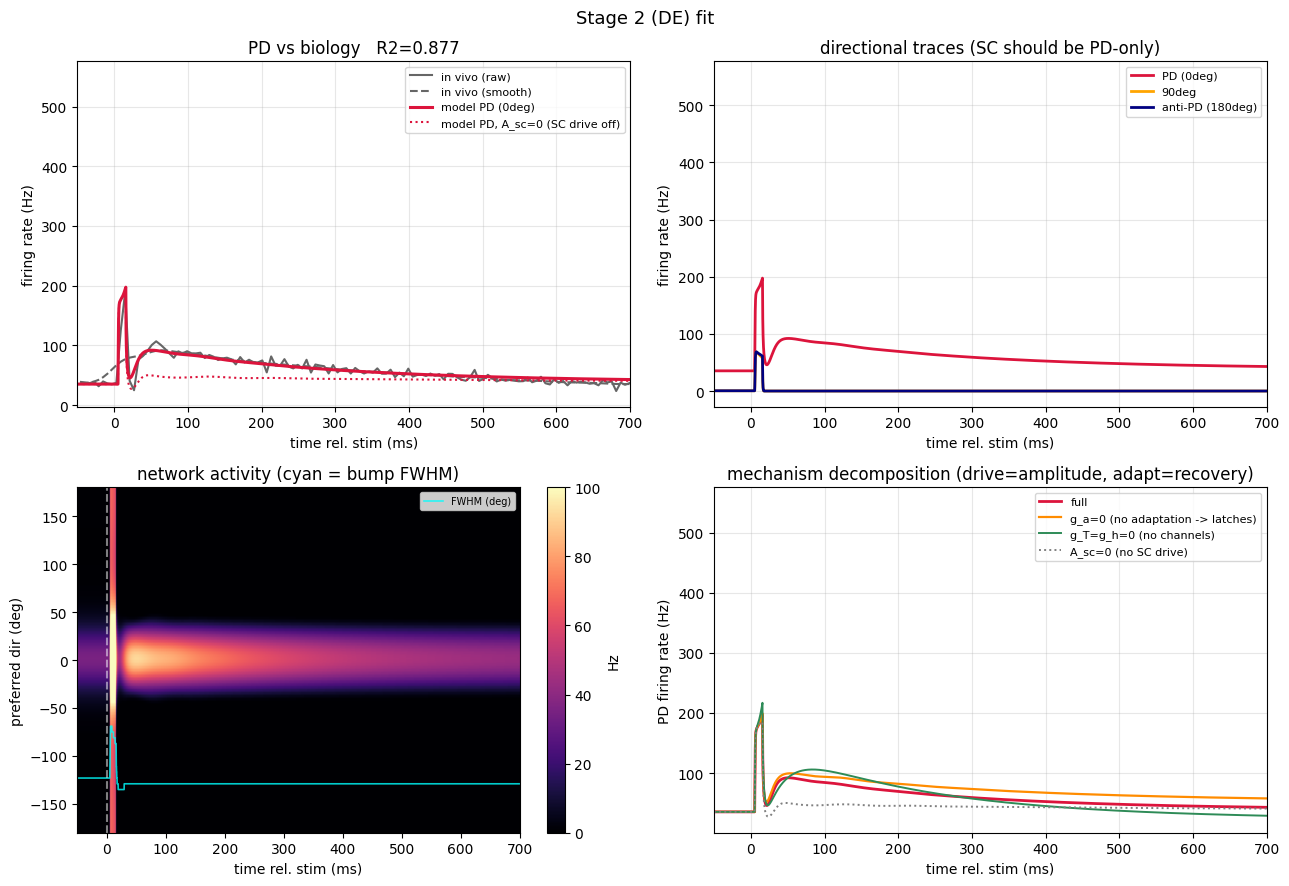

PD fit R2 = 0.877
SC-window PD max: full 92.0 Hz | A_sc=0 50.2 Hz
SC-window anti-PD max: 0.0 Hz (should be near baseline)
recovery: PD 45.1 Hz @500-700 (baseline ~37; should return)


np.float64(0.876900077571768)

In [5]:
# Full diagnostic: PD vs real PSTH (with ablation), directional traces,
# heatmap, and I_T/I_h channel decomposition.
diagnose(stage1_frozen, stage2_params, vivo=vivo, title="Stage 2 (DE) fit", t_hi=700)

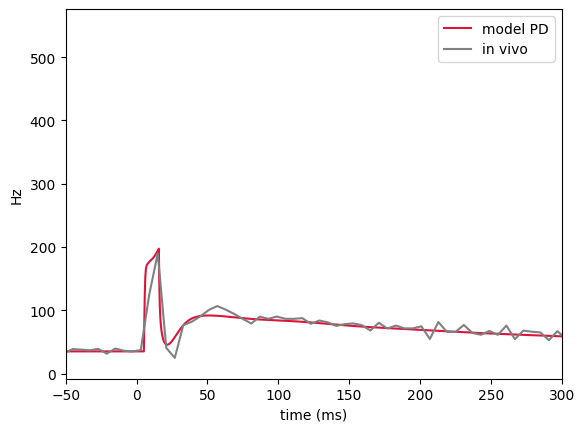

In [6]:
# Quick single-trace inspection (PD cell) if you want it raw.
t_model, rates = run_model_stim(
    *[stage1_frozen[k] for k in PARAM_NAMES[:10]], *stage2_params
)
plt.plot(t_model, rates[:, oe._IDX_0], color="crimson", label="model PD")
plt.plot(bins_plot, mean_vivo_rate, color="0.5", label="in vivo")
plt.xlim(-50, 300); plt.xlabel("time (ms)"); plt.ylabel("Hz"); plt.legend(); plt.show()

### Local polish + final mechanistic fit
L-BFGS-B refines the DE winner; then re-run the full diagnostic. Watch the **ablation** (dotted) and **anti-PD** (navy) traces — they are the evidence the SC is mechanistic and PD-only.

In [7]:
# Verification summary: the mechanistic checks (not just R2).
t, r = run_model_stim(*[stage1_frozen[k] for k in PARAM_NAMES[:10]], *stage2_params)
pd, anti = r[:, oe._IDX_0], r[:, oe._IDX_180]
s1 = [stage1_frozen[k] for k in PARAM_NAMES[:10]]
# ablations (indices WITHIN the stage-2 vector, PARAM_NAMES[10:]):
#   A_sc idx 17 -> tuned feedforward SC drive (sets the SC amplitude)
#   g_a  idx 15 -> global adaptation (drives recovery back to baseline)
no_drive = list(stage2_params); no_drive[17] = 0.0
no_adapt = list(stage2_params); no_adapt[15] = 0.0
_, r_nd = run_model_stim(*s1, *no_drive)
_, r_na = run_model_stim(*s1, *no_adapt)
m = (t > 40) & (t < 300)
_, ri = oe.run_model_idle(*s1)
prof = ri[-1, :]; pk = prof.max()
def fwhm(p): return (p >= p.max()/2).sum() * 360.0 / oe.N
def at(a, tt): return a[np.argmin(np.abs(t-tt))]
prof6 = r[np.argmin(np.abs(t-600)), :]
print(f"baseline bump peak    : {pk:.0f} Hz  (target ~40), FWHM {fwhm(prof):.0f} deg")
print(f"baseline secondary    : {100*prof[oe.OFF_LOBE].max()/max(pk,.01):.1f}% of peak  (want ~0)")
print(f"FC peak               : {pd[(t>=stage2_params[2])&(t<stage2_params[2]+12)].max():.0f} Hz  (data ~170)")
print(f"SC peak (PD)          : {pd[m].max():.0f} Hz @ {t[m][pd[m].argmax()]:.0f} ms  (data ~91 @ ~55)")
print(f"SC, drive off (A_sc=0): {r_nd[:,oe._IDX_0][m].max():.0f} Hz  -> drive supplies {100*(1-r_nd[:,oe._IDX_0][m].max()/max(pd[m].max(),.01)):.0f}% of SC")
print(f"anti-PD SC max        : {anti[m].max():.1f} Hz  (want ~0; PD-selective)")
print(f"RECOVERY @600ms       : PD {at(pd,600):.0f} Hz, FWHM {fwhm(prof6):.0f} deg  (baseline {pk:.0f}/{fwhm(prof):.0f})")
print(f"  no adaptation g_a=0 : PD @600 {at(r_na[:,oe._IDX_0],600):.0f} Hz  -> latches elevated (no recovery)")
print(f"I_HD={stage1_frozen['I_HD']:.1f}  W_GLOBAL={stage1_frozen['W_GLOBAL']:.1f}  "
      f"g_a={stage2_params[15]:.2f}  A_sc={stage2_params[17]:.1f}")


baseline bump peak    : 35 Hz  (target ~40), FWHM 57 deg


baseline secondary    : 6.0% of peak  (want ~0)
FC peak               : 198 Hz  (data ~170)
SC peak (PD)          : 92 Hz @ 51 ms  (data ~91 @ ~55)
SC, drive off (A_sc=0): 50 Hz  -> drive supplies 45% of SC
anti-PD SC max        : 0.0 Hz  (want ~0; PD-selective)
RECOVERY @600ms       : PD 45 Hz, FWHM 51 deg  (baseline 35/57)
  no adaptation g_a=0 : PD @600 60 Hz  -> latches elevated (no recovery)
I_HD=4.8  W_GLOBAL=2.2  g_a=1.92  A_sc=20.0


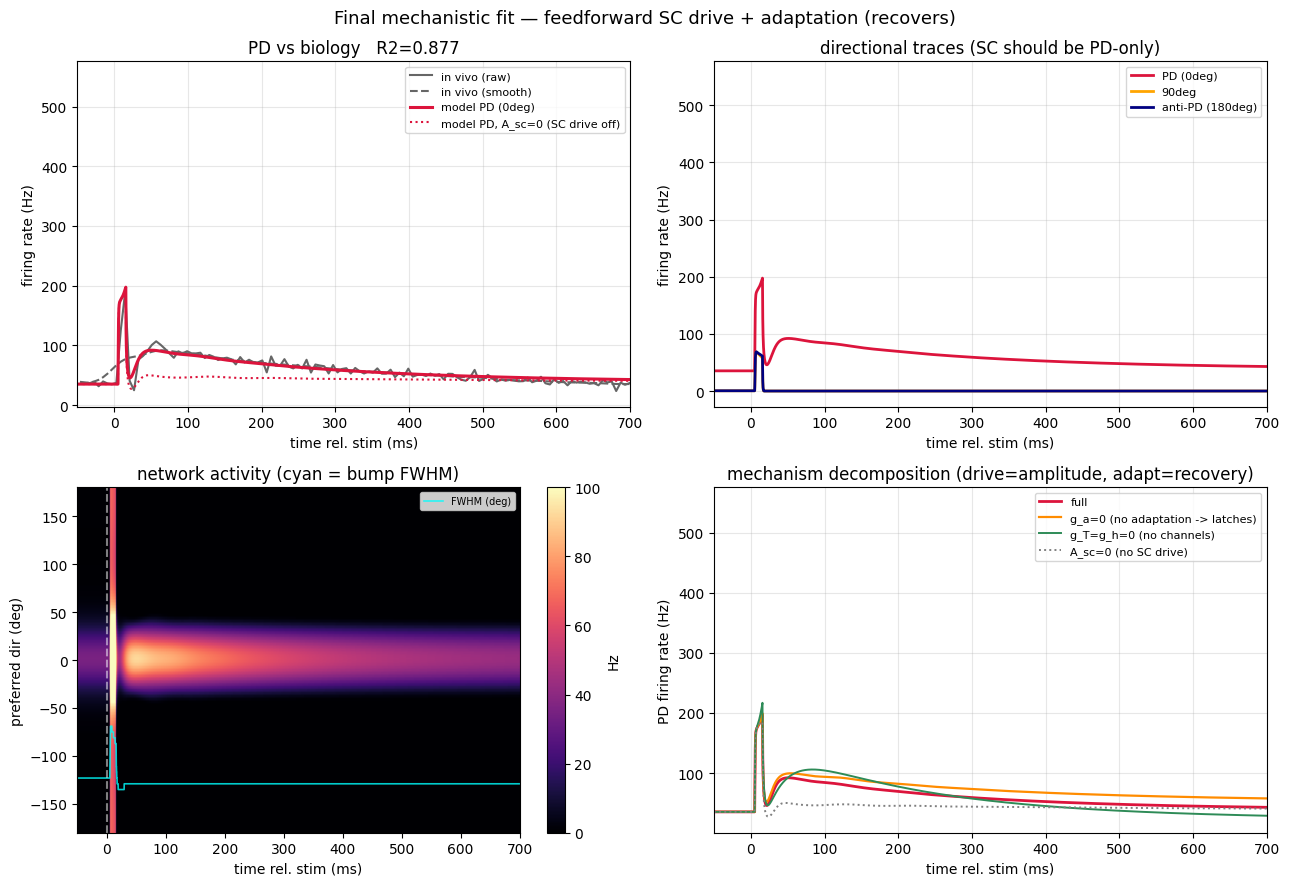

PD fit R2 = 0.877
SC-window PD max: full 92.0 Hz | A_sc=0 50.2 Hz
SC-window anti-PD max: 0.0 Hz (should be near baseline)
recovery: PD 45.1 Hz @500-700 (baseline ~37; should return)


In [8]:
# Final fit — full diagnostic + emergence/recovery evidence (window to 700 ms).
r2 = diagnose(stage1_frozen, stage2_params, vivo=vivo, t_hi=700,
              title="Final mechanistic fit — feedforward SC drive + adaptation (recovers)")
